# Question Answering Success Analysis

In this notebook the the performance of the boardgame rulebook question answering system will be analyzed. It loads question-answer results, computes success metrics, and visualizes the results with graphs.

In [13]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

%matplotlib inline

## Load Question Answering Results Data

Load the results data (CSV or JSON) containing ground truth answers and predicted answers. Update the file path as needed.

In [14]:
# Example: Load results from a CSV or JSON file
# Update the file path as needed
results_path = '../data/processed/qa_results.csv'  # or .json

# Try loading CSV, fallback to JSON
try:
    df = pd.read_csv(results_path)
except Exception:
    df = pd.read_json(results_path)

df.head()

,question,ground_truth,predicted
0,When do I increase my radiation?,When you move into a Radiation space or as a r...,fter ɮnishing this MoĄement they wouÐd increase
1,How do I win the mission?,When you complete all objectives laid out at t...,After you ﬁnish setting up the Map
2,How many players can play this game?,This game can be played by 1-4 players.,Single Stalker Mode
3,How does movement work?,"On your turn, when you use the Move action, yo...",Example: The Snork Moves toward the green Stal...
4,When do I roll dice to attack?,You roll dice to attack when you use your weap...,"When resolving Enemy Activation cards, conclud..."


## Preprocess and Explore Data

Clean and preprocess the data, handle missing values, and display basic statistics about the dataset.

In [15]:
# Drop rows with missing values
clean_df = df.dropna()

# Show basic statistics
print('Number of questions:', len(clean_df))
print('Columns:', clean_df.columns.tolist())
clean_df.describe(include='all')

Number of questions: 38
Columns: ['question', 'ground_truth', 'predicted']


,question,ground_truth,predicted
count,38,38,38
unique,38,38,13
top,When do I increase my radiation?,When you move into a Radiation space or as a r...,"When resolving Enemy Activation cards, conclud..."
freq,1,1,8


## Calculate Success Metrics Using Similarity

Compute and visualize fuzzy string similarity (token set ratio) for the question answering results. This provides a more realistic measure of model performance for free-form answers.

C:\Users\I544554\AppData\Local\Temp\ipykernel_35908\977814103.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['similarity'] = similarities
C:\Users\I544554\AppData\Local\Temp\ipykernel_35908\977814103.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['correct'] = clean_df['similarity'] >= threshold


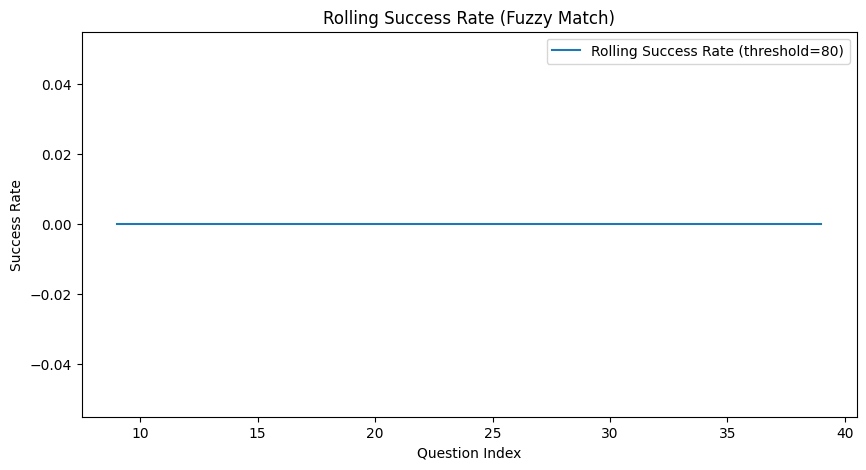

In [16]:
# Define threshold for fuzzy match success
threshold = 80
if 'similarity' not in clean_df.columns:
    try:
        from rapidfuzz import fuzz
    except ImportError:
        import sys, subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
        from rapidfuzz import fuzz
    similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(clean_df['ground_truth'], clean_df['predicted'])]
    clean_df['similarity'] = similarities
clean_df['correct'] = clean_df['similarity'] >= threshold

# Rolling success rate
window = 10
rolling_success = clean_df['correct'].rolling(window).mean()
plt.figure(figsize=(10,5))
plt.plot(rolling_success, label=f'Rolling Success Rate (threshold={threshold})')
plt.xlabel('Question Index')
plt.ylabel('Success Rate')
plt.title('Rolling Success Rate (Fuzzy Match)')
plt.legend()
plt.show()

## Fuzzy String Similarity Analysis

Since exact string match metrics are too strict for free-form answers, we use fuzzy string similarity to better gauge answer quality.

Mean similarity: 33.09


C:\Users\I544554\AppData\Local\Temp\ipykernel_35908\877489707.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['similarity'] = similarities


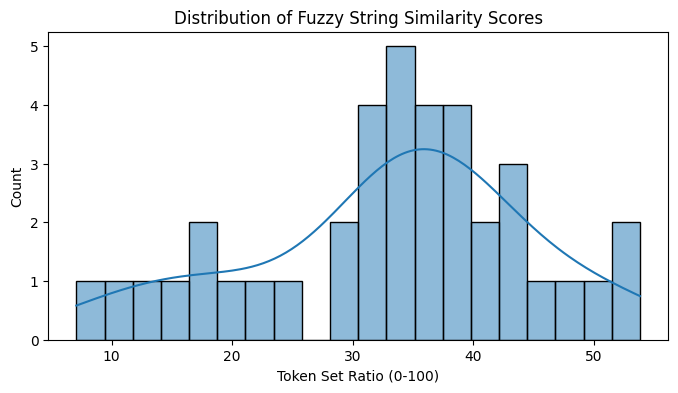

In [17]:
# Install rapidfuzz if not already installed
try:
    from rapidfuzz import fuzz
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
    from rapidfuzz import fuzz

# Use ground_truth and predicted columns from clean_df
y_true = clean_df['ground_truth']
y_pred = clean_df['predicted']

# Compute similarity scores
similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(y_true, y_pred)]
clean_df['similarity'] = similarities

print(f'Mean similarity: {np.mean(similarities):.2f}')
plt.figure(figsize=(8,4))
sns.histplot(similarities, bins=20, kde=True)
plt.title('Distribution of Fuzzy String Similarity Scores')
plt.xlabel('Token Set Ratio (0-100)')
plt.ylabel('Count')
plt.show()

## Fuzzy Match Confusion Matrix

We treat predictions as correct if their similarity is above the threshold, and plot a confusion matrix.

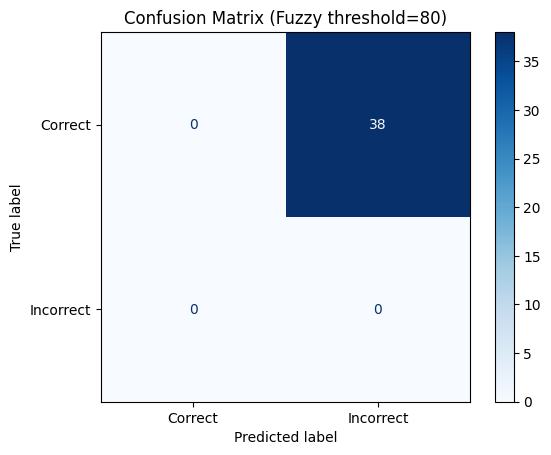

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# True: all answers are expected to be correct (since each row is a QA pair)
y_true_bin = np.ones(len(clean_df), dtype=int)
y_pred_bin = clean_df['correct'].astype(int)

cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[1,0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Correct', 'Incorrect'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (Fuzzy threshold={threshold})')
plt.show()

## Visualize Success Rate Over Time (Fuzzy Match)

We define a prediction as 'correct' if its similarity to the ground truth is above a threshold (e.g., 80).

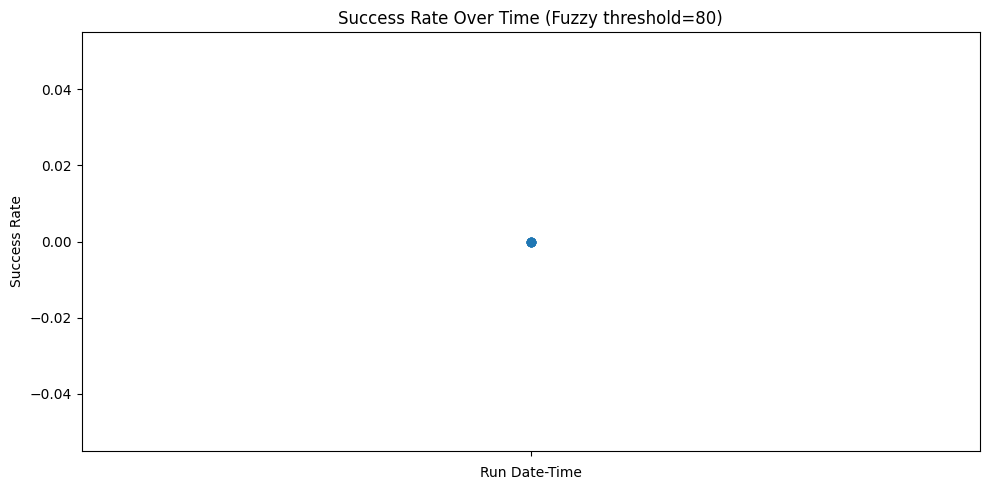

In [19]:
import glob
import re

# Find all archived qa_results files
archive_files = sorted(glob.glob('../data/processed/archive/qa_results_*.csv'))

# Extract datetime from filename for sorting
pattern = re.compile(r'qa_results_(\d{8}_\d{6})_\d+s\\.csv$|qa_results_(\d{8}_\d{6})_\d+s\.csv$')

def extract_dt(fname):
    match = pattern.search(fname)
    if match:
        return match.group(1) or match.group(2)
    return ''

archive_files = sorted(archive_files, key=extract_dt)

success_rates = []
datetimes = []
threshold = 80

for f in archive_files:
    df = pd.read_csv(f)
    if 'similarity' not in df.columns:
        # Compute similarity if not present
        try:
            from rapidfuzz import fuzz
        except ImportError:
            import sys, subprocess
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
            from rapidfuzz import fuzz
        similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(df['ground_truth'], df['predicted'])]
        df['similarity'] = similarities
    correct = (df['similarity'] >= threshold).mean()
    success_rates.append(correct)
    datetimes.append(extract_dt(f))

plt.figure(figsize=(10,5))
plt.plot(datetimes, success_rates, marker='o')
plt.xticks(rotation=45)
plt.xlabel('Run Date-Time')
plt.ylabel('Success Rate')
plt.title(f'Success Rate Over Time (Fuzzy threshold={threshold})')
plt.tight_layout()
plt.show()